In [1]:
from sklearn.datasets import fetch_openml 
mnist = fetch_openml('mnist_784', version=1)
mnist.keys() 

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

8


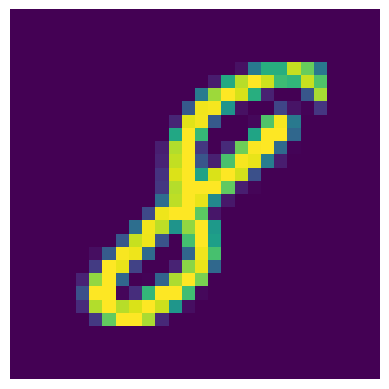

In [20]:
import matplotlib as mpl 
import matplotlib.pyplot as plt
import numpy as np
X, y = mnist["data"].to_numpy(), mnist["target"].to_numpy()
#print(X.shape)
#print(y.shape)
some_digit = X[7777]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image)
plt.axis("off")
print(y[7777])

In [23]:
#Convert y to a number:
y = y.astype(np.uint8)
#Split into train and test set, MNIST already did, 60000 vs 10000 
x_train = X[:60000]
y_train = y[:60000]

x_test = X[60000:]
y_test = y[60000:]

#Now, we create binary classifier; binary classifier only classes between 2 classes, for example, 8 and not 8:
y_train_8 = (y_train == 8)
y_test_8 = (y_test == 8)

#Use SGD classifier, look it up for our documentation:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(x_train, y_train_8)
sgd_clf.predict([some_digit]) 

array([False])

In [24]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, x_train, y_train_8, cv=3, scoring="accuracy") #accuracy is not a good metric for this dataset, because it is very imbalanced, 10% of the data is 8s, so if we just classify everything as not 8, we will get 90% accuracy, which is not good. We need to look at other metrics such as precision and recall.

array([0.909  , 0.9286 , 0.88285])

In [ ]:
#Now, let's do confusion matrix approach. For a confusion matrix, let's say we want to know how many times 5s is classified as 3s, we look at fifth row, 3rd column
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, x_train, y_train_8, cv=3)#Instead of returning accuracy, it returns predictions made on each test fold
from sklearn.metrics import confusion_matrix
#For confusion matrix, row represents ACTUAL class, columns represents PREDICTED class, so rows in this case are true non-8 and true 8s, columns are predicted non-8 and predicted 8s
confusion_matrix(y_train_8, y_train_pred)
#Result: 50006 true negatives, 4143 false positives. 1448 false negatives, 4403 true positives.
#A perfect binary classifier would have 0 false positives and 0 false negatives 

array([[50006,  4143],
       [ 1448,  4403]], dtype=int64)

In [ ]:
#use recall and precision:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_8, y_train_pred) #Precision is the ratio of true positives to all positive predictions, so it is 4403/(4403+4143) = 0.515; So when it classifies a picture as 8, it is only right 51.5% => Column 2 mean
recall_score(y_train_8, y_train_pred) #Recall is the ratio of true positives to all actual positives, so it is 4403/(4403+1448) = 0.753; so out of all pictures of truly 8s, it only detects 75.3% of them => Row 2 mean
print("Precision:", precision_score(y_train_8, y_train_pred))
print("Recall:", recall_score(y_train_8, y_train_pred))
#Check out the precision-recall tradeoff:

Precision: 0.515211794991809
Recall: 0.7525209365920356


In [29]:
#Also checkout F scores, which is the harmonic mean of precision and recall:
from sklearn.metrics import f1_score
f1_score(y_train_8, y_train_pred) #F1 score is 2* (precision * recall) / (precision + recall) = 0.612, which is not very good, but it is better than random guessing, which would give us an F1 score of 0.5

0.6116552059456831